In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv('../data/Dataset.csv')

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [3]:
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nColumns in dataset:")
print(df.columns.tolist())

Shape of dataset: (12316, 32)

First 5 rows:


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury



Columns in dataset:
['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Number_of_casualties', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident', 'Accident_severity']


In [4]:
columns_to_drop = [
    
    'Age_band_of_driver', 
    'Sex_of_driver', 
    'Educational_level', 
    'Vehicle_driver_relation', 
    'Driving_experience', 
    'Type_of_vehicle', 
    'Owner_of_vehicle', 
    'Service_year_of_vehicle', 
    'Defect_of_vehicle',
    'Vehicle_movement',
    'Sex_of_casualty', 
    'Age_band_of_casualty',
    'Work_of_casuality', 
    'Fitness_of_casuality', 
    'Pedestrian_movement',
    'Cause_of_accident'
    
]

# Drop only if they exist (safe)
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

In [5]:
df.shape

(12316, 16)

In [6]:
# Count missing values per column
missing_values = df.isnull().sum()

# Show only columns with missing values
missing_values

Time                             0
Day_of_week                      0
Area_accident_occured          239
Lanes_or_Medians               385
Road_allignment                142
Types_of_Junction              887
Road_surface_type              172
Road_surface_conditions          0
Light_conditions                 0
Weather_conditions               0
Type_of_collision              155
Number_of_vehicles_involved      0
Number_of_casualties             0
Casualty_class                   0
Casualty_severity                0
Accident_severity                0
dtype: int64

In [7]:
# Replace all remaining NaN values
df = df.fillna("Unknown")

In [8]:
# Check again for missing values
df.isnull().sum()

Time                           0
Day_of_week                    0
Area_accident_occured          0
Lanes_or_Medians               0
Road_allignment                0
Types_of_Junction              0
Road_surface_type              0
Road_surface_conditions        0
Light_conditions               0
Weather_conditions             0
Type_of_collision              0
Number_of_vehicles_involved    0
Number_of_casualties           0
Casualty_class                 0
Casualty_severity              0
Accident_severity              0
dtype: int64

In [9]:
# Check cleaned dataset
df.head()

print("\nFinal Shape:", df.shape)
print("\nRemaining Columns:\n", df.columns.tolist())


Final Shape: (12316, 16)

Remaining Columns:
 ['Time', 'Day_of_week', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Number_of_casualties', 'Casualty_class', 'Casualty_severity', 'Accident_severity']


In [10]:
# Number of unique values
print("Number of unique values:", df["Accident_severity"].nunique())

# List of unique values
print("Unique values:")
print(df["Accident_severity"].unique())

Number of unique values: 3
Unique values:
<StringArray>
['Slight Injury', 'Serious Injury', 'Fatal injury']
Length: 3, dtype: str


In [11]:
# Map accident severity to risk levels
risk_mapping = {
    "Slight Injury": "Low",
    "Serious Injury": "Medium",
    "Fatal injury": "High"
}

df["Risk_Level"] = df["Accident_severity"].map(risk_mapping)

# Check the results
print(df[["Accident_severity", "Risk_Level"]].head())
print("Final Risk Level Distribution:")
print(df['Risk_Level'].value_counts())
print("\nPercentage:")
print(round(df['Risk_Level'].value_counts(normalize=True) * 100, 2))

  Accident_severity Risk_Level
0     Slight Injury        Low
1     Slight Injury        Low
2    Serious Injury     Medium
3     Slight Injury        Low
4     Slight Injury        Low
Final Risk Level Distribution:
Risk_Level
Low       10415
Medium     1743
High        158
Name: count, dtype: int64

Percentage:
Risk_Level
Low       84.56
Medium    14.15
High       1.28
Name: proportion, dtype: float64


In [12]:
# === SIMPLIFY TIME ONLY (without removing other features) ===

# Create Hour from Time
df['Hour'] = pd.to_datetime(df['Time'], errors='coerce').dt.hour

# Create Time Period (Low cardinality - only 4 categories)
def get_time_period(hour):
    if pd.isna(hour):
        return "Unknown"
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df['Time_Period'] = df['Hour'].apply(get_time_period)

# Drop original Time if you were using it
if 'Time' in df.columns:
    df = df.drop(columns=['Time'])

print("Time simplified successfully!")
print(df[['Hour', 'Time_Period']].head())

Time simplified successfully!
   Hour Time_Period
0    17     Evening
1    17     Evening
2    17     Evening
3     1       Night
4     1       Night


In [13]:
df = df.drop(columns=['Accident_severity'], errors='ignore')

In [14]:
df.head()

,Day_of_week,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Casualty_class,Casualty_severity,Risk_Level,Hour,Time_Period
0,Monday,Residential areas,Unknown,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,2,na,na,Low,17,Evening
1,Monday,Office areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,2,na,na,Low,17,Evening
2,Monday,Recreational areas,other,Unknown,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside objects,2,2,Driver or rider,3,Medium,17,Evening
3,Sunday,Office areas,other,Tangent road with mild grade and flat terrain,Y Shape,Earth roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Pedestrian,3,Low,1,Night
4,Sunday,Industrial areas,other,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,na,na,Low,1,Night


In [15]:
# Features to use 
feature_columns = [
     'Day_of_week', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 
    'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 
    'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 
    'Number_of_casualties', 'Casualty_class', 'Hour', 'Time_Period'
    
]

X = df[feature_columns].copy()
y = df['Risk_Level']

print("Selected features:", X.columns.tolist())

Selected features: ['Day_of_week', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Number_of_casualties', 'Casualty_class', 'Hour', 'Time_Period']


In [16]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

le = LabelEncoder()
y_encoded = le.fit_transform(y)

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)],
    remainder='passthrough'
)

X_processed = preprocessor.fit_transform(X)

print("Processed Shape:", X_processed.shape)

Processed Shape: (12316, 90)


In [17]:
print(le.classes_)

['High' 'Low' 'Medium']


In [18]:
X_processed

array([[ 0.,  1.,  0., ...,  2.,  2., 17.],
       [ 0.,  1.,  0., ...,  2.,  2., 17.],
       [ 0.,  1.,  0., ...,  2.,  2., 17.],
       ...,
       [ 0.,  0.,  0., ...,  1.,  1., 13.],
       [ 0.,  0.,  0., ...,  2.,  1., 13.],
       [ 0.,  0.,  0., ...,  2.,  1., 13.]], shape=(12316, 90))

In [19]:
# First 2 rows of your selected features (before encoding)
print("=== First 2 Rows - Original Features ===")
display(X.head(10))        # Nice formatted view in Jupyter

=== First 2 Rows - Original Features ===


,Day_of_week,Area_accident_occured,Lanes_or_Medians,Road_allignment,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Casualty_class,Hour,Time_Period
0,Monday,Residential areas,Unknown,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,2,na,17,Evening
1,Monday,Office areas,Undivided Two way,Tangent road with flat terrain,No junction,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,2,na,17,Evening
2,Monday,Recreational areas,other,Unknown,No junction,Asphalt roads,Dry,Daylight,Normal,Collision with roadside objects,2,2,Driver or rider,17,Evening
3,Sunday,Office areas,other,Tangent road with mild grade and flat terrain,Y Shape,Earth roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,Pedestrian,1,Night
4,Sunday,Industrial areas,other,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,2,na,1,Night
5,Friday,Unknown,Unknown,Unknown,Y Shape,Unknown,Dry,Daylight,Normal,Vehicle with vehicle collision,1,1,Driver or rider,14,Afternoon
6,Wednesday,Residential areas,Undivided Two way,Tangent road with flat terrain,Crossing,Unknown,Dry,Daylight,Normal,Vehicle with vehicle collision,1,1,Driver or rider,17,Evening
7,Friday,Residential areas,other,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Daylight,Normal,Vehicle with vehicle collision,2,1,na,17,Evening
8,Friday,Industrial areas,other,Tangent road with flat terrain,Y Shape,Earth roads,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,1,Pedestrian,17,Evening
9,Friday,Residential areas,Undivided Two way,Tangent road with flat terrain,Y Shape,Asphalt roads,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,1,Passenger,17,Evening


In [20]:
print("=== First 2 Rows - After One-Hot Encoding ===")
print(X_processed[0:10])

# To see it better as DataFrame (with column names if possible)
# Note: Column names after one-hot are a bit messy, but useful for checking
feature_names = preprocessor.get_feature_names_out()
X_processed_df = pd.DataFrame(X_processed[:10], columns=feature_names)

print("\nFirst 2 rows with column names:")
display(X_processed_df)

=== First 2 Rows - After One-Hot Encoding ===
[[ 0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  1.  0.  0.
   0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  1.  0.
   0.  0.  0.  0.  0.  1.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0.  1.  0.  0.  2.  2. 17.]
 [ 0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  1.  0.  0.
   0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  1.  0.
   0.  0.  0.  0.  0.  1.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  1.  0.  1.  0.  0.  2.  2. 17.]
 [ 0.  1.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  1.  0.  1.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0

,cat__Day_of_week_Friday,cat__Day_of_week_Monday,cat__Day_of_week_Saturday,cat__Day_of_week_Sunday,cat__Day_of_week_Thursday,cat__Day_of_week_Tuesday,cat__Day_of_week_Wednesday,cat__Area_accident_occured_ Market areas,cat__Area_accident_occured_ Recreational areas,cat__Area_accident_occured_ Church areas,...,cat__Casualty_class_Passenger,cat__Casualty_class_Pedestrian,cat__Casualty_class_na,cat__Time_Period_Afternoon,cat__Time_Period_Evening,cat__Time_Period_Morning,cat__Time_Period_Night,remainder__Number_of_vehicles_involved,remainder__Number_of_casualties,remainder__Hour
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,2.0,17.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,2.0,17.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,2.0,17.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,2.0,1.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2.0,2.0,1.0
5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,14.0
6,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,17.0
7,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,1.0,17.0
8,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,2.0,1.0,17.0
9,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,1.0,17.0


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (9852, 90)
Test shape: (2464, 90)


=== Training Set Class Distribution ===
1    8331
2    1394
0     127
Name: count, dtype: int64

Percentage in Training Set:
1    84.56
2    14.15
0     1.29
Name: count, dtype: float64


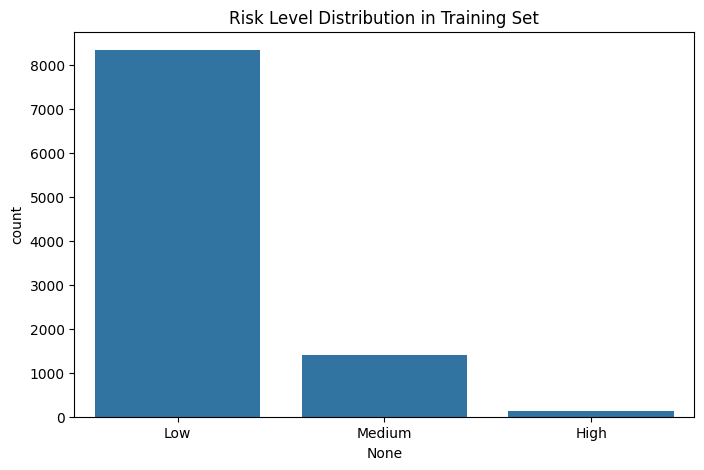

In [22]:
# Check balance in Training set
print("=== Training Set Class Distribution ===")
train_dist = pd.Series(y_train).value_counts()
print(train_dist)

print("\nPercentage in Training Set:")
print(round(train_dist / len(y_train) * 100, 2))

# Visualize
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x=pd.Series(le.inverse_transform(y_train)), 
              order=['Low', 'Medium', 'High'])
plt.title('Risk Level Distribution in Training Set')
plt.show()

In [23]:
# from imblearn.over_sampling import SMOTE
# # from imblearn.over_sampling import BorderlineSMOTE

# smote = SMOTE(
#      random_state=42,
#      sampling_strategy='auto'   # balances only minority classes
#  )
# # smote = BorderlineSMOTE(random_state=42)
# X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# # CHECK DISTRIBUTION
# y_train_balanced = pd.Series(y_train_balanced)

# print("=== Balanced Class Distribution ===")
# print(y_train_balanced.value_counts())


from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
import pandas as pd

pipeline = Pipeline([
    ("smote", SMOTE(
        sampling_strategy={
            0: 5000,
            2: 5000
        },
        random_state=42,
        k_neighbors=3
    )),
    ("under", RandomUnderSampler(
        sampling_strategy={
            0: 5000,
            1: 5000,
            2: 5000
        },
        random_state=42
    ))
])

X_train_balanced, y_train_balanced = pipeline.fit_resample(X_train, y_train)

y_train_balanced = pd.Series(y_train_balanced)

print(y_train_balanced.value_counts())

0    5000
1    5000
2    5000
Name: count, dtype: int64


In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import BatchNormalization, Dense, Dropout

# Stronger Model
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_balanced.shape[1],)),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    
    Dense(32, activation='relu'),
    Dropout(0.1),

    # Dense(16, activation='relu'),
    # Dropout(0.1),
    
    Dense(len(le.classes_), activation='softmax')
])

optimizer = Adam(learning_rate=0.0001)  # better starting LR
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)
]

history = model.fit(
    X_train_balanced, y_train_balanced,
    epochs=150,
    batch_size=64,
    validation_split=0.25,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4081 - loss: 1.2339 - val_accuracy: 0.1627 - val_loss: 1.5895 - learning_rate: 1.0000e-04
Epoch 2/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5717 - loss: 0.9424 - val_accuracy: 0.0168 - val_loss: 1.7564 - learning_rate: 1.0000e-04
Epoch 3/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6410 - loss: 0.8439 - val_accuracy: 0.0037 - val_loss: 2.0100 - learning_rate: 1.0000e-04
Epoch 4/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6770 - loss: 0.7932 - val_accuracy: 0.0032 - val_loss: 2.1037 - learning_rate: 1.0000e-04
Epoch 5/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7073 - loss: 0.7383 - val_accuracy: 0.0019 - val_loss: 2.0665 - learning_rate: 1.0000e-04
Epoch 6/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7299 - loss: 0.6921 - val_accuracy: 0.0040 - val_loss: 2.0208 - learning_rate: 1.0000e-04
Epoch 7/150
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 905us/step
=== Classification Report ===
              precision    recall  f1-score   support

        High       0.02      0.94      0.03        31
         Low       0.85      0.14      0.24      2084
      Medium       0.12      0.15      0.13       349

    accuracy                           0.15      2464
   macro avg       0.33      0.41      0.14      2464
weighted avg       0.74      0.15      0.22      2464



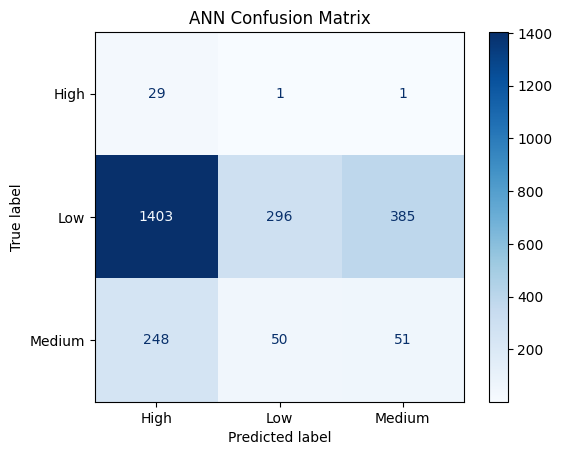

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title('ANN Confusion Matrix')
plt.show()

In [26]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy:", test_acc)

ValueError: Cannot take the length of shape with unknown rank.